In [1]:
import random
from collections import defaultdict
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np


class CountMinSketch:
    """Basic Count-Min Sketch implementation for switching activity tracking"""

    def __init__(self, width: int = 1000, depth: int = 5):
        """
        Initialize Count-Min Sketch

        Args:
            width: Number of counters in each hash array
            depth: Number of hash functions (rows)
        """
        self.width = width
        self.depth = depth
        self.sketch = np.zeros((depth, width), dtype=np.float32)

        # Initialize hash function parameters
        self.hash_params = []
        for i in range(depth):
            # Use different random seeds for each hash function
            a = random.randint(1, 2**31)
            b = random.randint(1, 2**31)
            self.hash_params.append((a, b))

    def _hash(self, key: int, row: int) -> int:
        """Hash function for a given key and row"""
        a, b = self.hash_params[row]
        # Universal hash: (a*x + b) mod p mod width
        return ((a * key + b) % 2147483647) % self.width

    def update(self, key: int, value: float = 1.0):
        """
        Update sketch with a value for a key

        Args:
            key: Node ID or hash of node name
            value: Switching activity value to add
        """
        for d in range(self.depth):
            col = self._hash(key, d)
            self.sketch[d][col] += value

    def query(self, key: int) -> float:
        """
        Query estimated value for a key

        Returns:
            Minimum estimate (CMS property: always overestimates)
        """
        estimates = []
        for d in range(self.depth):
            col = self._hash(key, d)
            estimates.append(self.sketch[d][col])

        return min(estimates)

    def merge(self, other: "CountMinSketch") -> "CountMinSketch":
        """Merge another sketch into this one (element-wise addition)"""
        if self.width != other.width or self.depth != other.depth:
            raise ValueError("Sketches must have same dimensions for merging")

        merged = CountMinSketch(self.width, self.depth)
        merged.sketch = self.sketch + other.sketch
        return merged

    def reset(self):
        """Reset all counters to zero"""
        self.sketch.fill(0)


class TemporalSwitchingAnalyzer:
    """Analyze temporal patterns of switching activity"""

    def __init__(self, num_time_windows: int = 20, window_size: int = 50):
        """
        Initialize temporal analyzer

        Args:
            num_time_windows: Number of time windows to track
            window_size: Number of cycles per window
        """
        self.num_windows = num_time_windows
        self.window_size = window_size

        # Create CMS for each time window
        self.window_sketches = [
            CountMinSketch(width=500, depth=4) for _ in range(num_time_windows)
        ]

        # Current window index
        self.current_window = 0
        self.cycle_counter = 0

        # For periodicity detection
        self.periodicity_buffer: Dict[int, List[int]] = defaultdict(list)

    def process_timestep(self, toggled_nodes: List[int]):
        """Process toggle events at a specific timestep"""
        # Add toggles to current window
        for node_id in toggled_nodes:
            self.window_sketches[self.current_window].update(node_id)

        # Store for periodicity analysis
        for node_id in toggled_nodes:
            self.periodicity_buffer[node_id].append(self.cycle_counter)

        # Advance window if needed
        self.cycle_counter += 1
        if self.cycle_counter >= self.window_size:
            self.current_window = (self.current_window + 1) % self.num_windows
            self.cycle_counter = 0
            # Clear new window (optional - depends on use case)
            # self.window_sketches[self.current_window].reset()

    def get_temporal_profile(self, node_id: int) -> np.ndarray:
        """Get switching activity profile across time windows"""
        profile = []
        for i, sketch in enumerate(self.window_sketches):
            activity = sketch.query(node_id) / self.window_size
            profile.append(activity)

        return np.array(profile)

    def detect_burstiness(self, node_id: int) -> Dict:
        """Detect bursty switching patterns"""
        profile = self.get_temporal_profile(node_id)

        if len(profile) == 0:
            return {"burstiness": 0, "max_activity": 0, "avg_activity": 0}

        mean_activity = np.mean(profile)
        std_activity = np.std(profile)

        # Burstiness metric
        if mean_activity + std_activity > 0:
            burstiness = (std_activity - mean_activity) / (std_activity + mean_activity)
        else:
            burstiness = 0

        # Find bursts (windows with activity > 2σ above mean)
        threshold = mean_activity + 2 * std_activity
        burst_windows = np.where(profile > threshold)[0]

        return {
            "burstiness": burstiness,
            "mean_activity": mean_activity,
            "std_activity": std_activity,
            "max_activity": np.max(profile),
            "burst_windows": burst_windows.tolist(),
            "burst_count": len(burst_windows),
        }

    def detect_periodicity(self, node_id: int, max_period: int = 100) -> Dict:
        """Detect periodic switching patterns"""
        toggle_times = np.array(self.periodicity_buffer.get(node_id, []))

        if len(toggle_times) < 3:
            return {"periodic": False, "period": 0, "confidence": 0}

        # Simple periodicity detection using autocorrelation
        if len(toggle_times) > 0:
            intervals = np.diff(toggle_times)

            if len(intervals) > 1:
                # Check if intervals are roughly equal
                mean_interval = np.mean(intervals)
                std_interval = np.std(intervals)

                # Coefficient of variation
                cv = std_interval / mean_interval if mean_interval > 0 else float("inf")

                is_periodic = cv < 0.3  # 30% variation threshold
                confidence = 1.0 - min(cv, 1.0)

                return {
                    "periodic": is_periodic,
                    "period": mean_interval,
                    "confidence": confidence,
                    "cv": cv,
                }

        return {"periodic": False, "period": 0, "confidence": 0}

    def find_simultaneous_switching(
        self, threshold: float = 0.3
    ) -> List[Tuple[int, float]]:
        """Find time windows with high simultaneous switching"""
        hot_windows = []

        for i, sketch in enumerate(self.window_sketches):
            # Estimate total toggles in window
            # Simplified: use average of all counters
            if sketch.sketch.size > 0:
                avg_toggles = np.mean(sketch.sketch)
                window_activity = avg_toggles / self.window_size

                if window_activity > threshold:
                    hot_windows.append((i, window_activity))

        # Sort by activity
        hot_windows.sort(key=lambda x: x[1], reverse=True)
        return hot_windows


class CurrentEnvelopeEstimator:
    """Estimate current envelope from switching activity"""

    def __init__(self, transition_time: float = 50e-12, voltage: float = 1.0):
        """
        Initialize current envelope estimator

        Args:
            transition_time: Rise/fall time in seconds
            voltage: Supply voltage in volts
        """
        self.transition_time = transition_time
        self.voltage = voltage
        self.capacitance_map: Dict[int, float] = {}

        # CMS for tracking switching
        self.cms = CountMinSketch(width=1000, depth=5)
        self.total_cycles = 0

    def add_node(self, node_id: int, capacitance: float):
        """Add node with capacitance"""
        self.capacitance_map[node_id] = capacitance

    def process_toggles(self, toggles: List[Tuple[int, int]]):
        """Process toggle events"""
        max_cycle = 0
        for node_id, cycle in toggles:
            self.cms.update(node_id)
            self.total_cycles = max(self.total_cycles, cycle + 1)
            max_cycle = max(max_cycle, cycle)

    def estimate_peak_current(self, node_id: int) -> float:
        """Estimate peak current for a switching event"""
        C = self.capacitance_map.get(node_id, 1e-15)
        # I_peak ≈ C * dV/dt
        dt = self.transition_time
        peak_current = C * self.voltage / dt
        return peak_current

    def estimate_current_envelope(
        self, time_resolution: float = 10e-12, duration: float = 1e-9
    ) -> np.ndarray:
        """
        Estimate worst-case current envelope

        Args:
            time_resolution: Time step in seconds
            duration: Total duration in seconds
        """
        num_samples = int(duration / time_resolution)
        time_axis = np.linspace(0, duration, num_samples)
        current_envelope = np.zeros(num_samples)

        # Get hot nodes (simplified - check first 100 nodes)
        hot_nodes = []
        for node_id in list(self.capacitance_map.keys())[:100]:
            activity = self.cms.query(node_id) / max(self.total_cycles, 1)
            if activity > 0.1:  # High activity threshold
                peak_current = self.estimate_peak_current(node_id)
                hot_nodes.append((node_id, activity, peak_current))

        print(f"Using {len(hot_nodes)} hot nodes for envelope estimation")

        # For each hot node, add its contribution
        for node_id, activity, peak_current in hot_nodes[:20]:  # Limit to top 20
            # Model current pulse as triangular
            pulse_duration = self.transition_time
            pulse_samples = int(pulse_duration / time_resolution)

            if pulse_samples < 2:
                pulse_samples = 2

            # Triangular pulse
            pulse = np.concatenate(
                [
                    np.linspace(0, peak_current, pulse_samples // 2),
                    np.linspace(peak_current, 0, pulse_samples // 2),
                ]
            )

            if len(pulse) < pulse_samples:
                pulse = np.pad(pulse, (0, pulse_samples - len(pulse)))

            # Distribute pulses according to activity
            # Simplified: Poisson distribution of events
            avg_interval_cycles = 1.0 / activity if activity > 0 else float("inf")
            avg_interval_time = avg_interval_cycles / (1e9)  # Assuming 1GHz

            # Add pulses to envelope
            t = 0
            while t < duration:
                start_sample = int(t / time_resolution)
                end_sample = start_sample + len(pulse)

                if end_sample < num_samples:
                    current_envelope[start_sample:end_sample] += pulse

                # Next event time (exponential distribution)
                t += np.random.exponential(avg_interval_time)

        return time_axis, current_envelope


def demo_temporal_analysis():
    """Demonstrate temporal analysis and current envelope estimation"""
    print("\n" + "=" * 60)
    print("DEMO 3: Temporal Analysis and Current Envelope")
    print("=" * 60)

    # Create temporal analyzer
    temporal = TemporalSwitchingAnalyzer(num_time_windows=10, window_size=100)

    # Create synthetic toggle patterns
    np.random.seed(42)

    print("\nGenerating synthetic temporal patterns...")

    # Create nodes with different temporal patterns
    nodes = {
        "periodic_clock": 5001,  # Regular periodic toggling
        "bursty_node": 5002,  # Bursty switching
        "random_node": 5003,  # Random switching
        "quiet_node": 5004,  # Low activity
    }

    # Generate toggle patterns
    all_toggles = []

    # Periodic clock (toggles every other cycle)
    print("  - Periodic clock node (toggles every cycle)")
    for cycle in range(1000):
        if cycle % 2 == 0:  # 50% activity
            toggled = [nodes["periodic_clock"]]
            temporal.process_timestep(toggled)
            all_toggles.append((nodes["periodic_clock"], cycle))

    # Bursty node (clustered toggles)
    print("  - Bursty node (clustered toggles)")
    burst_start = 0
    while burst_start < 1000:
        # Create burst of 20 cycles
        for offset in range(20):
            cycle = burst_start + offset
            if cycle < 1000:
                toggled = [nodes["bursty_node"]]
                temporal.process_timestep(toggled)
                all_toggles.append((nodes["bursty_node"], cycle))

        # Skip some cycles
        burst_start += np.random.randint(50, 200)

    # Random node
    print("  - Random node (Poisson process)")
    for cycle in range(1000):
        if np.random.random() < 0.15:  # 15% probability
            toggled = [nodes["random_node"]]
            temporal.process_timestep(toggled)
            all_toggles.append((nodes["random_node"], cycle))

    # Quiet node (low activity)
    print("  - Quiet node (low activity)")
    for cycle in range(1000):
        if np.random.random() < 0.02:  # 2% probability
            toggled = [nodes["quiet_node"]]
            temporal.process_timestep(toggled)
            all_toggles.append((nodes["quiet_node"], cycle))

    # Analyze temporal patterns
    print("\n" + "-" * 40)
    print("TEMPORAL PATTERN ANALYSIS")
    print("-" * 40)

    for name, node_id in nodes.items():
        print(f"\n{name}:")

        # Get temporal profile
        profile = temporal.get_temporal_profile(node_id)

        # Detect burstiness
        burst_info = temporal.detect_burstiness(node_id)
        print(f"  Burstiness: {burst_info['burstiness']:.3f}")
        print(f"  Mean activity: {burst_info['mean_activity']:.3f}")
        print(f"  Max activity: {burst_info['max_activity']:.3f}")
        print(f"  Burst count: {burst_info['burst_count']}")

        # Detect periodicity
        period_info = temporal.detect_periodicity(node_id)
        if period_info["periodic"]:
            print(
                f"  Periodic: Yes (period: {period_info['period']:.1f} cycles, "
                f"confidence: {period_info['confidence']:.2f})"
            )
        else:
            print(f"  Periodic: No (confidence: {period_info['confidence']:.2f})")

    # Find windows with high simultaneous switching
    print("\nWindows with high simultaneous switching:")
    hot_windows = temporal.find_simultaneous_switching(threshold=0.2)
    for window_idx, activity in hot_windows[:5]:
        print(f"  Window {window_idx}: activity = {activity:.3f}")

    # Current envelope estimation
    print("\n" + "-" * 40)
    print("CURRENT ENVELOPE ESTIMATION")
    print("-" * 40)

    # Create current envelope estimator
    current_estimator = CurrentEnvelopeEstimator(
        transition_time=50e-12,  # 50ps transition
        voltage=1.0,
    )

    # Add nodes with capacitances
    for name, node_id in nodes.items():
        # Assign different capacitances
        if name == "periodic_clock":
            capacitance = 10e-15  # Large clock buffer
        elif name == "bursty_node":
            capacitance = 5e-15  # Moderate
        else:
            capacitance = 2e-15  # Small

        current_estimator.add_node(node_id, capacitance)

    # Process all toggles
    current_estimator.process_toggles(all_toggles)

    # Estimate current envelope
    print("\nEstimating current envelope...")
    time_axis, current_envelope = current_estimator.estimate_current_envelope(
        time_resolution=5e-12,  # 5ps resolution
        duration=200e-12,  # 200ps window
    )

    print(f"Peak current: {np.max(current_envelope) * 1e3:.2f} mA")
    print(f"Average current: {np.mean(current_envelope) * 1e3:.2f} mA")

    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot 1: Temporal profiles
    colors = ["red", "blue", "green", "purple"]
    for idx, (name, node_id) in enumerate(nodes.items()):
        profile = temporal.get_temporal_profile(node_id)
        axes[0, 0].plot(
            profile, label=name, color=colors[idx], marker="o", markersize=4
        )

    axes[0, 0].set_title("Temporal Switching Profiles")
    axes[0, 0].set_xlabel("Time Window")
    axes[0, 0].set_ylabel("Activity Factor")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Burstiness comparison
    burstiness_values = []
    node_names = []
    for name, node_id in nodes.items():
        burst_info = temporal.detect_burstiness(node_id)
        burstiness_values.append(burst_info["burstiness"])
        node_names.append(name)

    bars = axes[0, 1].bar(node_names, burstiness_values, color=colors[: len(nodes)])
    axes[0, 1].set_title("Burstiness Comparison")
    axes[0, 1].set_ylabel("Burstiness Index")
    axes[0, 1].set_ylim([-1, 1])
    axes[0, 1].axhline(y=0, color="black", linestyle="-", alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[0, 1].text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom" if height >= 0 else "top",
        )

    # Plot 3: Current envelope
    axes[1, 0].plot(time_axis * 1e12, current_envelope * 1e3, "r-", linewidth=2)
    axes[1, 0].fill_between(
        time_axis * 1e12, 0, current_envelope * 1e3, alpha=0.3, color="red"
    )
    axes[1, 0].set_title("Estimated Current Envelope")
    axes[1, 0].set_xlabel("Time (ps)")
    axes[1, 0].set_ylabel("Current (mA)")
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Histogram of current values
    axes[1, 1].hist(current_envelope * 1e3, bins=30, edgecolor="black", alpha=0.7)
    axes[1, 1].set_title("Current Distribution")
    axes[1, 1].set_xlabel("Current (mA)")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("temporal_current_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

    return temporal, current_estimator

 Run demo 3


DEMO 3: Temporal Analysis and Current Envelope

Generating synthetic temporal patterns...
  - Periodic clock node (toggles every cycle)
  - Bursty node (clustered toggles)
  - Random node (Poisson process)
  - Quiet node (low activity)

----------------------------------------
TEMPORAL PATTERN ANALYSIS
----------------------------------------

periodic_clock:
  Burstiness: 0.000
  Mean activity: 0.500
  Max activity: 1.000
  Burst count: 0
  Periodic: No (confidence: 0.00)

bursty_node:
  Burstiness: 0.350
  Mean activity: 0.160
  Max activity: 1.000
  Burst count: 1
  Periodic: No (confidence: 0.00)

random_node:
  Burstiness: 0.300
  Mean activity: 0.166
  Max activity: 1.000
  Burst count: 1
  Periodic: No (confidence: 0.00)

quiet_node:
  Burstiness: 0.500
  Mean activity: 0.015
  Max activity: 0.150
  Burst count: 1
  Periodic: Yes (period: 1.0 cycles, confidence: 1.00)

Windows with high simultaneous switching:

----------------------------------------
CURRENT ENVELOPE ESTIMATIO

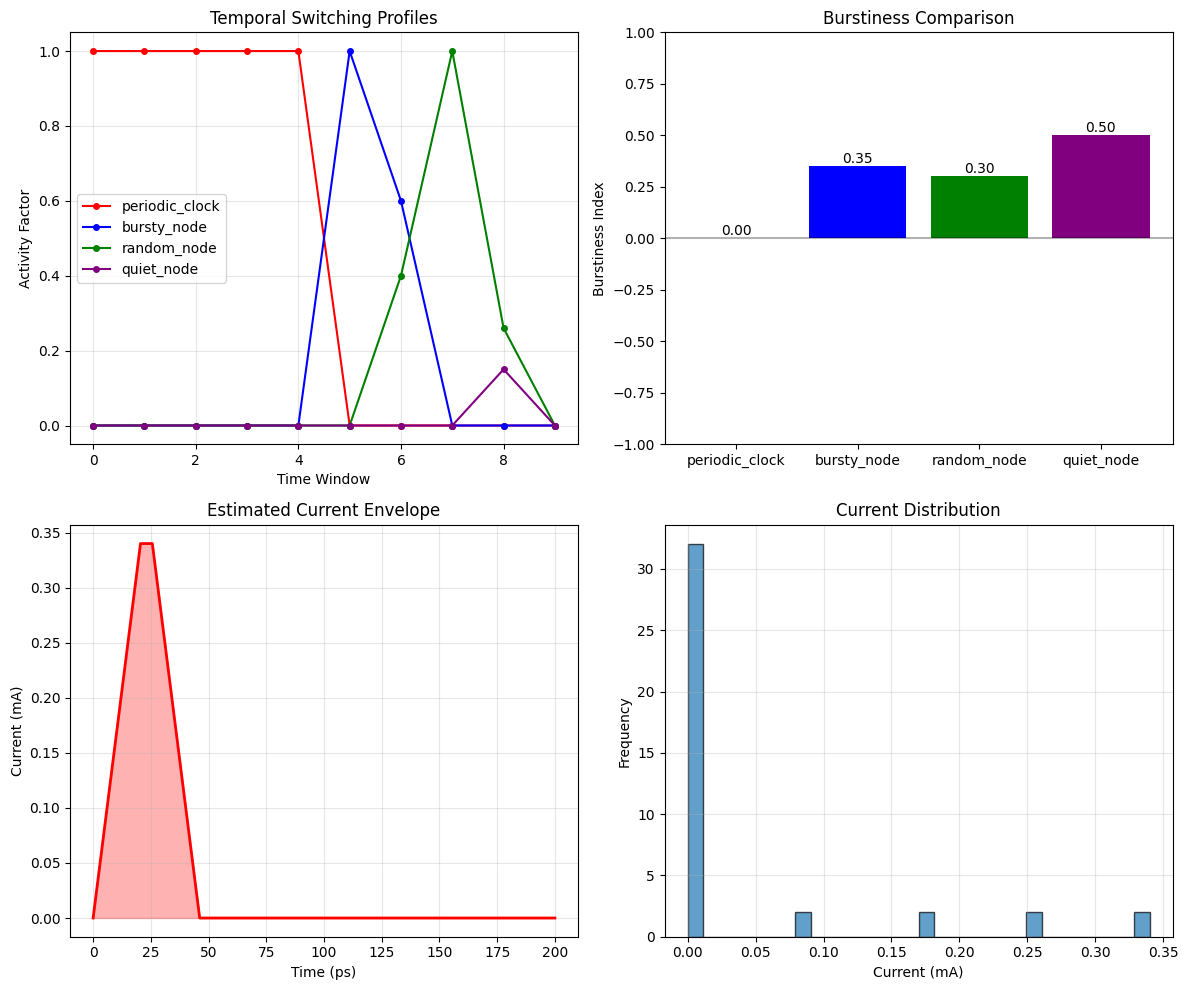

In [2]:
temporal_analyzer, current_estimator = demo_temporal_analysis()